# Customer Churn Prediction and Business Analysis

**Goal:** find out which telecom customers are likely to leave (churn), understand *why* they leave, and estimate how much monthly revenue is at risk.

**Dataset:** IBM Telco Customer Churn (7,043 customers, 21 columns). File: `Telco-Customer-Churn.csv`

**Steps**
1. Load and understand the data
2. Clean the data
3. Business analysis (EDA)
4. Prepare data for machine learning
5. Train and compare models
6. Tune the best model with GridSearchCV
7. Important features
8. Business impact and recommendations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report, ConfusionMatrixDisplay)

import warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

## 1. Load and understand the data

In [2]:
df = pd.read_csv("Telco-Customer-Churn.csv")
print("Rows, columns:", df.shape)
df.head()

Rows, columns: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
# check missing values
df.isnull().sum().sum()

np.int64(0)

In [5]:
# target column
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

## 2. Clean the data

- `TotalCharges` is stored as text. Some rows have a blank space instead of a number, so it has to be converted to numeric.
- `customerID` is just an ID, it is not useful for prediction.
- Convert `Churn` from Yes/No to 1/0.

In [6]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Blank TotalCharges:", df["TotalCharges"].isnull().sum())

# these customers have tenure 0 (just joined), so total charges = 0
print(df[df["TotalCharges"].isnull()]["tenure"].unique())
df["TotalCharges"] = df["TotalCharges"].fillna(0)

Blank TotalCharges: 11
[0]


In [7]:
df = df.drop("customerID", axis=1)
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# check duplicates
print("Duplicate rows:", df.duplicated().sum())
# kept: different customers can have exactly the same plan and charges
df.shape

Duplicate rows: 22


(7043, 20)

## 3. Business analysis (EDA)

Questions:
- What % of customers leave?
- Which contract / internet / payment type has the most churn?
- Do new customers leave more than old customers?
- How much monthly revenue is lost because of churn?

Overall churn rate: 26.5%


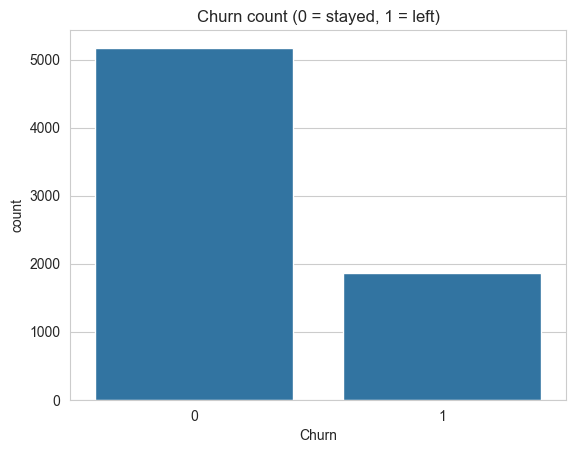

In [8]:
churn_rate = df["Churn"].mean() * 100
print(f"Overall churn rate: {churn_rate:.1f}%")

sns.countplot(x="Churn", data=df)
plt.title("Churn count (0 = stayed, 1 = left)")
plt.show()

In [9]:
# churn rate for different groups
def churn_by(col):
    table = df.groupby(col)["Churn"].agg(["count", "mean"])
    table.columns = ["customers", "churn_rate_%"]
    table["churn_rate_%"] = (table["churn_rate_%"] * 100).round(1)
    return table.sort_values("churn_rate_%", ascending=False)

for col in ["Contract", "InternetService", "PaymentMethod", "TechSupport"]:
    print(churn_by(col), "\n")

                customers  churn_rate_%
Contract                               
Month-to-month       3875          42.7
One year             1473          11.3
Two year             1695           2.8 

                 customers  churn_rate_%
InternetService                         
Fiber optic           3096          41.9
DSL                   2421          19.0
No                    1526           7.4 

                           customers  churn_rate_%
PaymentMethod                                     
Electronic check                2365          45.3
Mailed check                    1612          19.1
Bank transfer (automatic)       1544          16.7
Credit card (automatic)         1522          15.2 

                     customers  churn_rate_%
TechSupport                                 
No                        3473          41.6
Yes                       2044          15.2
No internet service       1526           7.4 



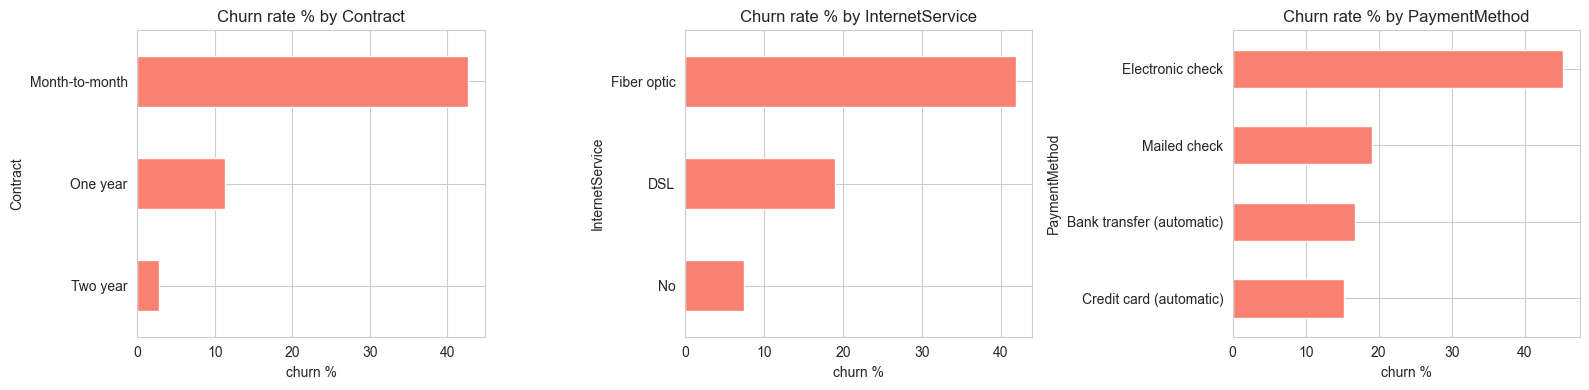

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["Contract", "InternetService", "PaymentMethod"]):
    rates = df.groupby(col)["Churn"].mean() * 100
    rates.sort_values().plot(kind="barh", ax=ax, color="salmon")
    ax.set_title(f"Churn rate % by {col}")
    ax.set_xlabel("churn %")
plt.tight_layout()
plt.show()

              customers  churn_rate_%
tenure_group                         
0-12 months        2186          47.4
13-24 months       1024          28.7
25-48 months       1594          20.4
49-72 months       2239           9.5


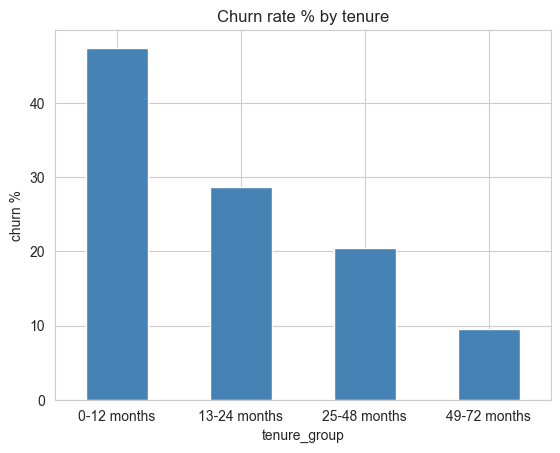

In [11]:
# tenure = number of months with the company
df["tenure_group"] = pd.cut(df["tenure"], bins=[-1, 12, 24, 48, 72],
                            labels=["0-12 months", "13-24 months", "25-48 months", "49-72 months"])
print(churn_by("tenure_group"))

(df.groupby("tenure_group")["Churn"].mean() * 100).plot(kind="bar", color="steelblue")
plt.title("Churn rate % by tenure")
plt.ylabel("churn %")
plt.xticks(rotation=0)
plt.show()

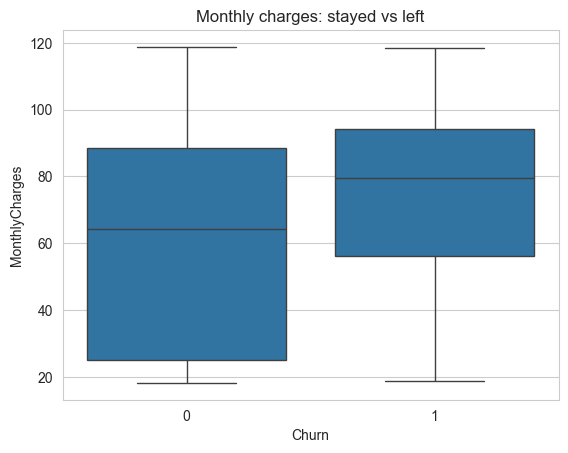

Churn
0    61.27
1    74.44
Name: MonthlyCharges, dtype: float64


In [12]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly charges: stayed vs left")
plt.show()

print(df.groupby("Churn")["MonthlyCharges"].mean().round(2))

In [13]:
# revenue lost because of churn
total_monthly_revenue = df["MonthlyCharges"].sum()
lost_monthly_revenue = df[df["Churn"] == 1]["MonthlyCharges"].sum()

print(f"Total monthly revenue : ${total_monthly_revenue:,.0f}")
print(f"Revenue from churned customers: ${lost_monthly_revenue:,.0f} per month")
print(f"Share of revenue lost : {lost_monthly_revenue / total_monthly_revenue * 100:.1f}%")

Total monthly revenue : $456,117
Revenue from churned customers: $139,131 per month
Share of revenue lost : 30.5%


**Observations from EDA** (check these against the output above)
- Month-to-month contract customers churn much more than one-year and two-year contract customers.
- Fiber optic users and electronic check payers have the highest churn.
- Most churn happens in the first 12 months.
- Customers who left were paying higher monthly charges on average.

## 4. Prepare data for machine learning

- One-hot encoding for categorical columns (`pd.get_dummies`)
- 80/20 train-test split, `stratify` so both parts have the same churn %
- Scale numeric columns (needed for Logistic Regression)

In [14]:
data = df.drop("tenure_group", axis=1)
data = pd.get_dummies(data, drop_first=True)
print("Shape after encoding:", data.shape)

X = data.drop("Churn", axis=1)
y = data["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Churn % train:", round(y_train.mean()*100, 1), " test:", round(y_test.mean()*100, 1))

Shape after encoding: (7043, 31)
Train: (5634, 30)  Test: (1409, 30)
Churn % train: 26.5  test: 26.5


In [15]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

scaler = StandardScaler()
X_train_s = X_train.copy()
X_test_s = X_test.copy()
X_train_s[num_cols] = scaler.fit_transform(X_train[num_cols])   # fit only on train data
X_test_s[num_cols] = scaler.transform(X_test[num_cols])

## 5. Train and compare models

Only about 26% of customers churn, so **accuracy alone is misleading** (a model that always says "No churn" gets ~73% accuracy).
So I also check **precision, recall, F1 and ROC-AUC for the churn class**. `class_weight="balanced"` gives more importance to the churn class.

In [16]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42),
}

results = []
for name, model in models.items():
    model.fit(X_train_s, y_train)
    pred = model.predict(X_test_s)
    prob = model.predict_proba(X_test_s)[:, 1]
    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred),
        "recall": recall_score(y_test, pred),
        "f1": f1_score(y_test, pred),
        "roc_auc": roc_auc_score(y_test, prob),
    })

results_df = pd.DataFrame(results).round(3)
results_df

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.738,0.504,0.783,0.614,0.842
1,Decision Tree,0.735,0.500,0.807,0.618,0.831
2,Random Forest,0.789,0.627,0.503,0.558,0.824


## 6. Tune Logistic Regression with GridSearchCV

5-fold stratified cross validation, scoring = F1 (balance between catching churners and false alarms).

In [17]:
param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "class_weight": [None, "balanced"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=cv, scoring="f1")
grid.fit(X_train_s, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV F1:", round(grid.best_score_, 3))

Best parameters: {'C': 0.1, 'class_weight': 'balanced'}
Best CV F1: 0.63


              precision    recall  f1-score   support

      Stayed       0.90      0.73      0.81      1035
     Churned       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409

ROC-AUC: 0.841


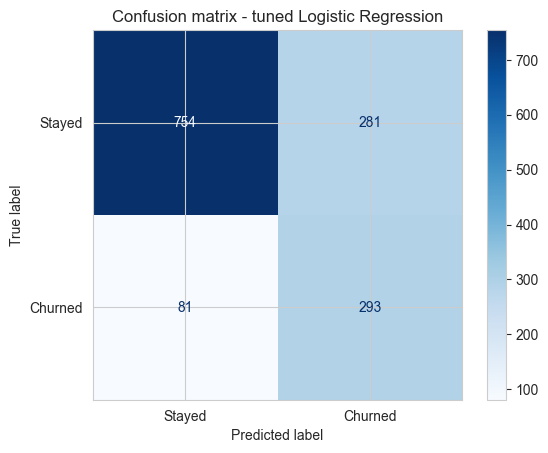

In [18]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test_s)
y_prob = best_model.predict_proba(X_test_s)[:, 1]

print(classification_report(y_test, y_pred, target_names=["Stayed", "Churned"]))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 3))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=["Stayed", "Churned"]).plot(cmap="Blues")
plt.title("Confusion matrix - tuned Logistic Regression")
plt.show()

## 7. Which features matter most?

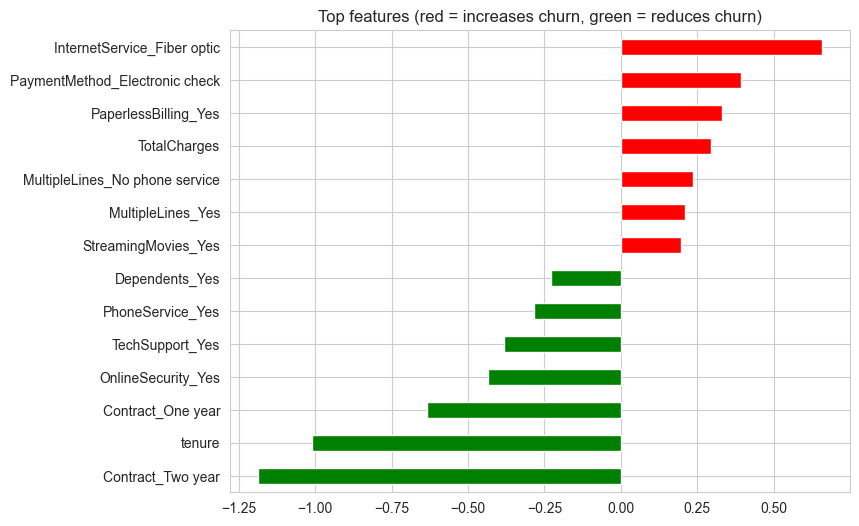

In [19]:
coef = pd.Series(best_model.coef_[0], index=X.columns).sort_values()
top = pd.concat([coef.head(7), coef.tail(7)])

top.plot(kind="barh", figsize=(8, 6), color=["green"]*7 + ["red"]*7)
plt.title("Top features (red = increases churn, green = reduces churn)")
plt.show()

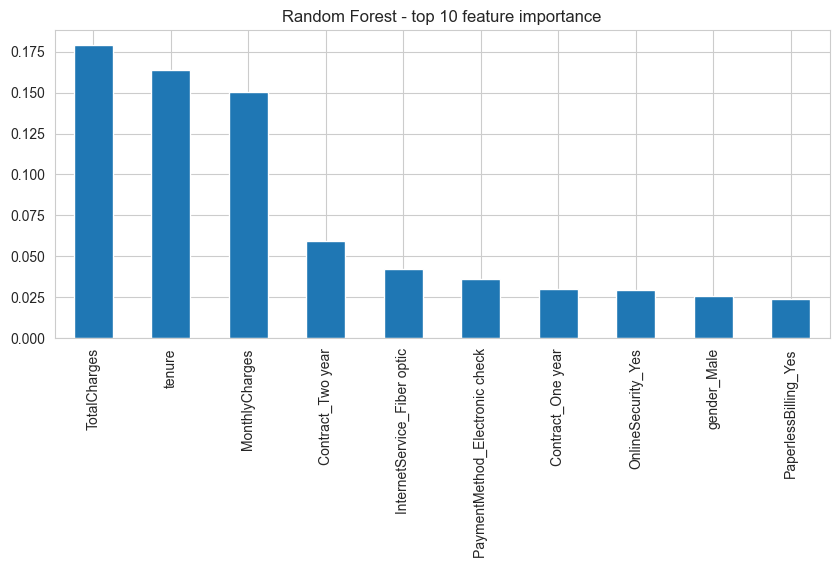

In [20]:
rf = models["Random Forest"]
importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
importance.head(10).plot(kind="bar", figsize=(10, 4))
plt.title("Random Forest - top 10 feature importance")
plt.show()

## 8. Business impact

In [21]:
test_data = df.loc[X_test.index].copy()
test_data["predicted"] = y_pred

caught = test_data[(test_data["Churn"] == 1) & (test_data["predicted"] == 1)]
all_churners = test_data[test_data["Churn"] == 1]

print("Churners in test set:", len(all_churners))
print("Churners caught by the model:", len(caught))
print(f"Monthly revenue of churners in test set: ${all_churners['MonthlyCharges'].sum():,.0f}")
print(f"Monthly revenue of churners the model flagged: ${caught['MonthlyCharges'].sum():,.0f}")
print(f"-> {caught['MonthlyCharges'].sum() / all_churners['MonthlyCharges'].sum() * 100:.1f}% of at-risk revenue can be targeted with retention offers")

Churners in test set: 374
Churners caught by the model: 293
Monthly revenue of churners in test set: $27,215
Monthly revenue of churners the model flagged: $22,422
-> 82.4% of at-risk revenue can be targeted with retention offers


**Recommendations**
1. Offer discounts to move month-to-month customers to one-year or two-year contracts.
2. Give extra attention (onboarding, support calls) to customers in their first 12 months.
3. Check the fiber optic service quality and pricing, because churn is highest there.
4. Encourage automatic payment methods instead of electronic check.
5. Use the model every month to create a list of high-risk customers for the retention team.

**Limitations**
- The data is one snapshot, there is no time information.
- Precision is moderate: some customers flagged as "will churn" would have stayed, so retention offers have a cost.

In [22]:
# save the model and columns for the Streamlit app
import joblib
joblib.dump(best_model, "churn_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(list(X.columns), "model_columns.pkl")
print("saved")

saved
